<a href="https://colab.research.google.com/github/Micaliang/Micaliang/blob/main/Week10_Plotting_Visualization_20260526_Ori.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 10: Plotting and Visualization using Matplotlib**
Please refer to the textbook: "Python for Data Analysis" by Wes McKinney for details of this topic (***Chapter 9***)

## **Learning Outcomes**

By the end of this lesson, students should be able to:

1. Explain the difference between a Matplotlib Figure and Axes.
2. Create basic plots such as line plots, scatter plots, histograms, and bar charts.
3. Customise plots using titles, axis labels, ticks, legends, colours, markers, and line styles.
4. Create multiple plots in one figure using subplots.
5. Save plots into common file formats such as PNG, PDF, and SVG.
6. Use pandas and seaborn to produce common statistical visualisations more efficiently.

In [ ]:
# Mount to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **From Matplotlib to pandas and seaborn**

Matplotlib is the foundation for many Python plotting tools.
- In this lecture, we first learn the core Matplotlib concepts: Figure, Axes, labels, legends, subplots, and saving plots.
- After that, we briefly explore how pandas and seaborn build on Matplotlib to produce common statistical plots more quickly.

# **Load Matplotlib library**

In [ ]:
# Load library
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import seaborn as sns

# **Figure vs Axes**

In Matplotlib, a **Figure** is the whole canvas or page that contains the visualisation.

An **Axes** is the actual plotting area where data is drawn.
- It contains the x-axis, y-axis, ticks, labels, title, and plotted data.

A single Figure can contain one Axes or multiple Axes.
- When we create subplots, we are placing multiple Axes inside the same Figure.

## **Two ways to use Matplotlib**

Matplotlib can be used in two common ways:

1. **pyplot style**, for example **`plt.plot(...)`**
2. **object-oriented style**, for example **`fig, ax = plt.subplots()`** followed by **`ax.plot(...)`**

- For simple plots, **`plt.plot()`** is convenient.
- For reports, subplots, and customised figures, the object-oriented style is usually clearer because we explicitly control the Figure and Axes.

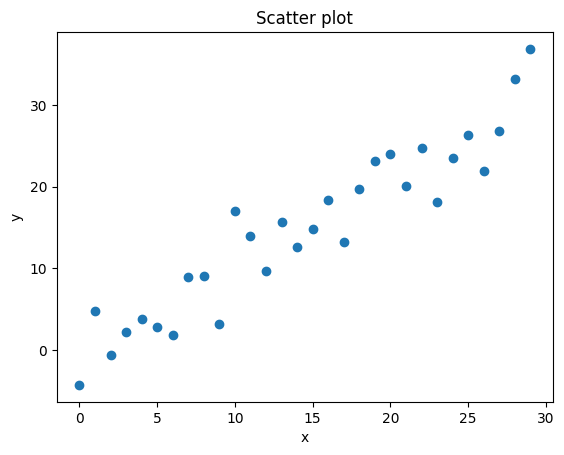

In [ ]:
# Create and display a simple scatter plot
x = np.arange(30)
y = x + 3*np.random.default_rng(12345).standard_normal(30)

# Creates a figure and a set of axes
fig, ax = plt.subplots()
ax.scatter(x, y)
ax.set(title="Scatter plot", xlabel="x", ylabel="y")
fig.show()

## **Simple 2 × 2 Subplot Grid**

A subplot grid allows us to display several plots in one Figure.
- This is useful when we want to compare different visualisations side by side.

- The argument **`constrained_layout=True`** automatically adjusts spacing between subplots so that titles, labels, and tick labels do not overlap.

- When saving a figure, use **`fig.savefig(...)`** or **`plt.savefig(...)`** before **`plt.show()`** to avoid accidentally saving an empty figure in some environments.

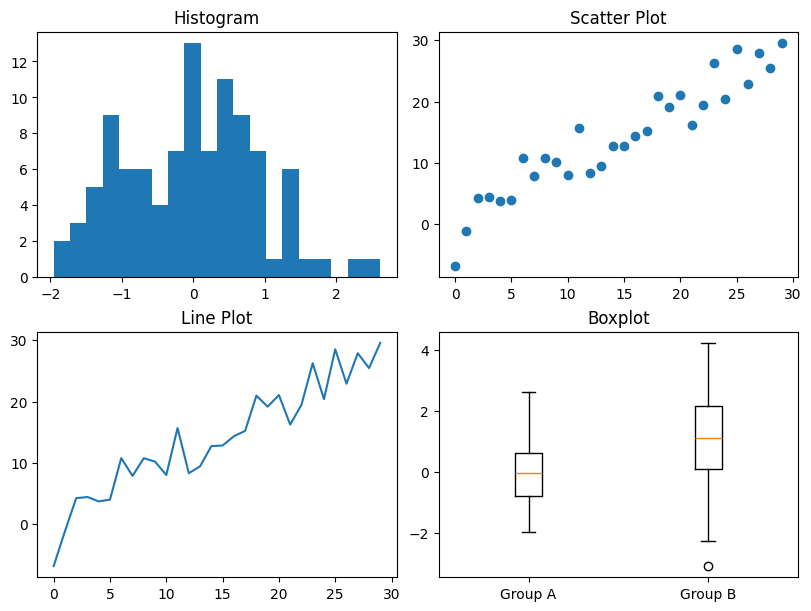

In [ ]:
rng = np.random.default_rng(12345)

data1 = rng.normal(0, 1, 100)
data2 = rng.normal(1, 1.5, 100)
x = np.arange(30)
y = x + rng.normal(0, 3, 30)

# Using subplot_mosaic to define a 2x2 grid
fig, mosaic_axs = plt.subplot_mosaic([['A', 'B'], ['C', 'D']], figsize=(8, 6), constrained_layout=True)

# (1) Histogram
mosaic_axs['A'].hist(data1, bins=20)
mosaic_axs['A'].set_title("Histogram")

# (2) Scatter plot
mosaic_axs['B'].scatter(x, y)
mosaic_axs['B'].set_title("Scatter Plot")

# (3) Line plot
mosaic_axs['C'].plot(x, y)
mosaic_axs['C'].set_title("Line Plot")

# (4) Boxplot
mosaic_axs['D'].boxplot([data1, data2], tick_labels=["Group A", "Group B"])
mosaic_axs['D'].set_title("Boxplot")

# To save the figures
plt.savefig('/content/drive/MyDrive/STQD6014_Executive/_SEM2_20252026/_Plots/Figs_Combo.pdf')

plt.show()

# **Customising Individual Plots**

In this section, we learn how to customise common plot elements such as **bins, transparency, line style, colour, marker, ticks, labels, and legends.**

### **Histogram**


*   **`bins`**: Bins are the intervals into which the data is divided for counting and display in the histogram.
    - Having 20 bins means the data range will be split into 20 intervals
*   **`alpha`**: controls the transparency of the bars.
    - A value of 1.0 would be completely opaque, while 0.0 would be completely transparent.



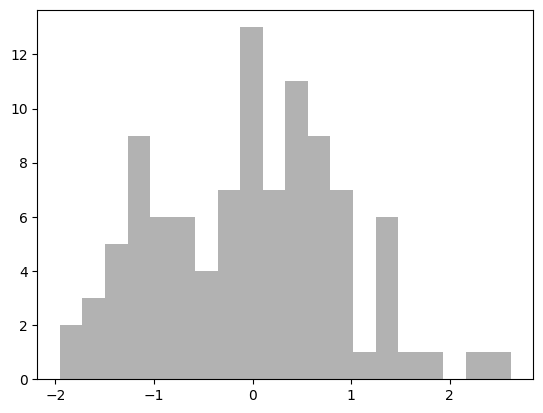

In [ ]:
# Histogram
rng = np.random.default_rng(12345)
plt.hist(rng.standard_normal(100), bins=20,
         color='black', alpha=0.3);

### **linestyle**
1. Some common options:

*   `'-'` (**solid**): This is the default linestyle and creates a solid line.
*   `'--'` (**dashed**): Creates a dashed line.
*   `'-.'` (**dash-dot**): Creates a line with alternating dashes and dots.
*   `':'` (**dotted**): Creates a dotted line.
* `None`, `' '`, or `''`: no line is drawn. This is useful when we want to show markers only.

2. We can also use:
*   **`solid`**: `-`
*   **`dashed`**: `--`
*   **`dashdot`**: `-.`
*   **`dotted`**: `:`

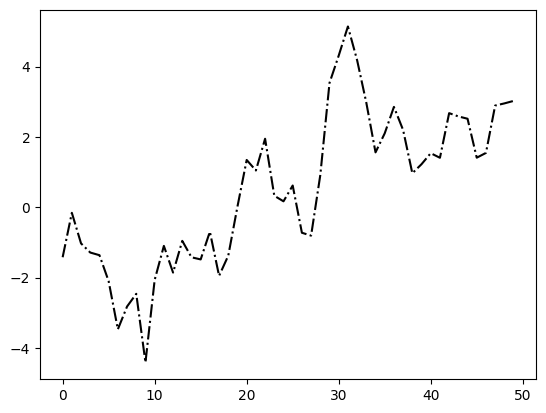

In [ ]:
# Line plot
rng = np.random.default_rng(12345)
plt.plot(rng.standard_normal(50).cumsum(),
         color='black', linestyle='-.');

# **Colours, Markers, and Line Styles**

Matplotlib allows us to customise the appearance of a plot using:

- **`color`**: controls the colour of the line or marker.
- **`linestyle`**: controls the type of line, such as solid, dashed, dotted, or dash-dot.
- **`marker`**: controls the symbol used to mark each data point.

Colours can be specified using common colour names, short colour codes such as **`'r'`** for red, or hex colour codes such as `**'#CECECE'`**.

* For more information about hex colour codes, can visit this website: https://htmlcolorcodes.com/



### **Marker**
specify a symbol or shape that will be placed at each data point on the plotted line

### **Other Marker Options**

Matplotlib offers a wide variety of marker options. Here are a few examples:

* `'.'`: Point
* `','`: Pixel
* `'o'`: Circle
* `'v'`: Triangle down
* `'^'`: Triangle up
* `'<'`: Triangle left
* `'>'`: Triangle right
* `'s'`: Square
* `'+'`: Plus
* `'x'`: X
* `'D'`: Diamond
* `'d'`: Thin diamond
* `'|'`: Vertical line
* `'_'`: Horizontal line

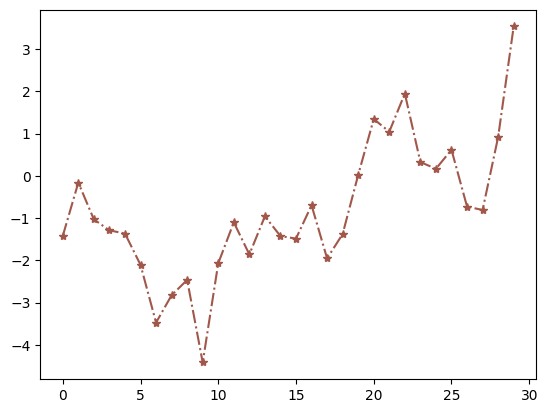

In [ ]:
# Adding marker on line plot
rng = np.random.default_rng(12345)
plt.plot(rng.standard_normal(30).cumsum(), color='#A1574A',
        linestyle='-.', marker='*');

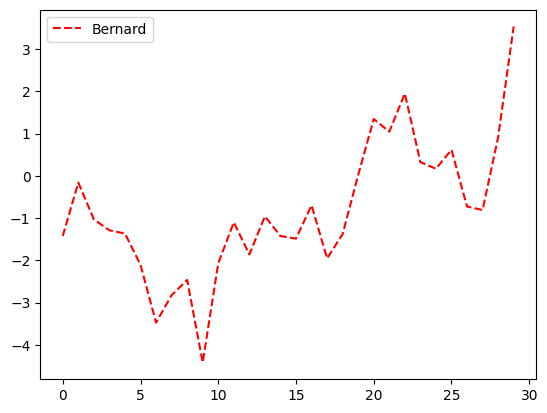

In [ ]:
# Drawstyle default
rng = np.random.default_rng(12345)
data = rng.standard_normal(30).cumsum()
plt.plot(data, color='r', linestyle='dashed', label='Bernard')
plt.legend();

### **Setting the title, axis labels, ticks, and tick labels**
When setting custom tick labels, make sure the
- **number of labels matches the number of tick positions**.

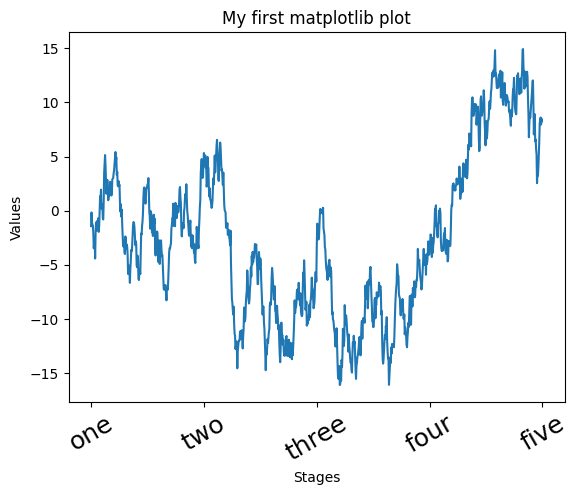

In [ ]:
# An example
rng = np.random.default_rng(12345)
fig, ax = plt.subplots()
ax.plot(rng.standard_normal(1000).cumsum())

# Change the x-axis tick positions
ax.set_xticks([0, 250, 500, 750, 1000])

# label the x-axis ticks with names
ax.set_xticklabels(['one', 'two', 'three', 'four', 'five'],
                   rotation=30, fontsize=18)

ax.set_xlabel('Stages')
ax.set_ylabel('Values')
ax.set_title('My first matplotlib plot');

### **Adding Legends**

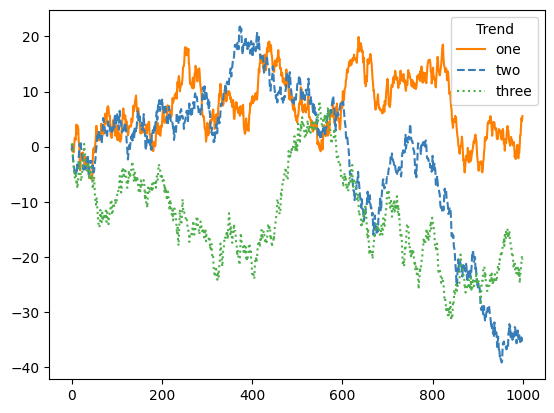

In [ ]:
# Adding legend
fig, ax = plt.subplots()
ax.plot(np.random.randn(1000).cumsum(), color='#FF7F00', label='one')
ax.plot(np.random.randn(1000).cumsum(), color='#377EB8', linestyle='dashed',
        label='two')
ax.plot(np.random.randn(1000).cumsum(), color='#4DAF4A', linestyle='dotted',
        label='three')
ax.legend(title='Trend');

### **Adding Shapes to a Plot**

Matplotlib can also add geometric shapes such as rectangles, circles, polygons, ellipses, and regular polygons.
- These are useful for **annotation, highlighting regions, or creating custom diagrams**.

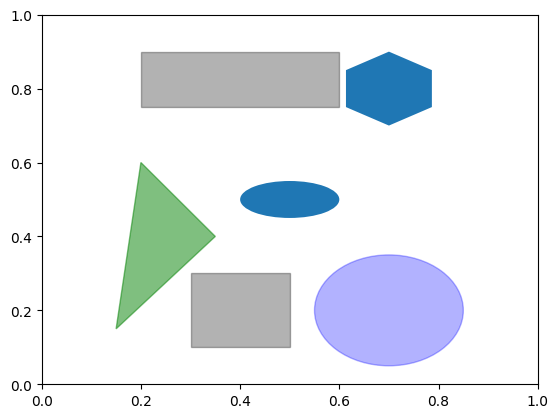

In [ ]:
# Adding shapes to a plot
fig, ax = plt.subplots()

rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color='black', alpha=0.3)
circ = plt.Circle((0.7, 0.2), 0.15, color='blue', alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]],
                   color='green', alpha=0.5)
sqr = plt.Rectangle((0.3, 0.1), 0.2, 0.2, color='black', alpha=0.3)

# Add ellipse
ellipse = patches.Ellipse((0.5,0.5), 0.2, 0.1)

# Add regular hexagon
hexagon = patches.RegularPolygon((0.7,0.8), 6, radius=0.1)

ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)
ax.add_patch(sqr)
ax.add_patch(ellipse)
ax.add_patch(hexagon);

### **Saving Plots to File**

1. File format: '***.png***','***.pdf***','***.svg***','***.ps***','***.eps***', .etc


In [ ]:
# Saving the plot
fig.savefig('/content/drive/MyDrive/STQD6014_Executive/_SEM2_20252026/_Plots/shapes.jpeg', dpi=400, bbox_inches="tight")

### **Notes:**
If you are **not using Google Colab** and want to save the file to **some other places**, replace `'shapes.jpeg'` with your **own directory path**.

### **Matplotlib Configuration**

Matplotlib allows us to change default settings using `plt.rc()`.

For example:

```python
plt.rc('figure', figsize=(10, 10))
```
- sets the default figure size to 10 × 10 inches for plots created after this line

In [ ]:
# Challenge 1: To set the previous shapes figure to 5 x 5
plt.rc('figure', figsize=(5, 5))

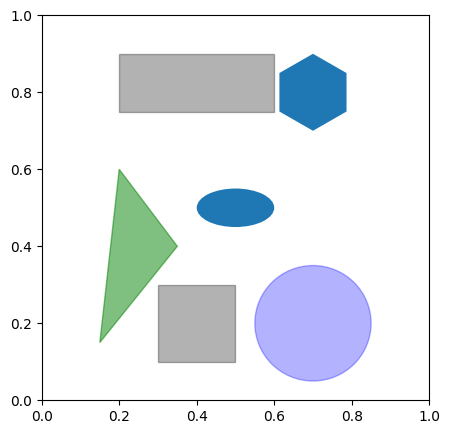

In [ ]:
# Adding shapes to a plot : Attention
fig, ax = plt.subplots()

rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color='black', alpha=0.3)
circ = plt.Circle((0.7, 0.2), 0.15, color='blue', alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]],
                   color='green', alpha=0.5)
sqr = plt.Rectangle((0.3, 0.1), 0.2, 0.2, color='black', alpha=0.3)

# Add ellipse
ellipse = patches.Ellipse((0.5,0.5),0.2,0.1)

# Add regular hexagon
hexagon = patches.RegularPolygon((0.7,0.8),6, radius=0.1)

ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)
ax.add_patch(sqr)
ax.add_patch(ellipse)
ax.add_patch(hexagon);

### **To reset Matplotlib to its default settings, use:**

In [ ]:
# Reset to default value
plt.rcdefaults()

## **Plotting with pandas and seaborn**

So far, we have used Matplotlib directly.
- In practice, we often use pandas and seaborn to create common plots more quickly.

- **pandas plotting** is convenient when the data is already stored in a Series or DataFrame.
- **seaborn** is a high-level statistical visualisation library built on top of Matplotlib. It is especially useful for comparing groups, showing distributions, and creating statistical plots.

### **Line plots**

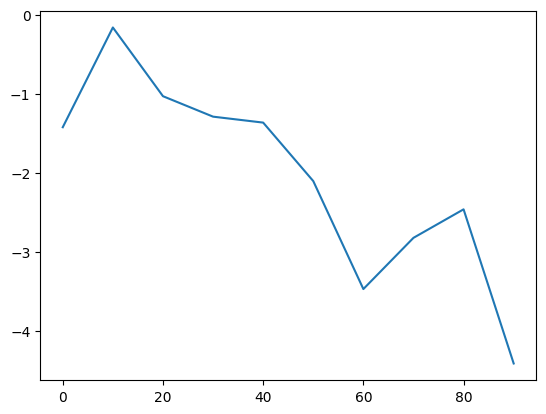

In [ ]:
# Using series data
rng = np.random.default_rng(12345)
s = pd.Series(rng.standard_normal(10).cumsum(),
              index=np.arange(0, 100, 10))
s.plot();

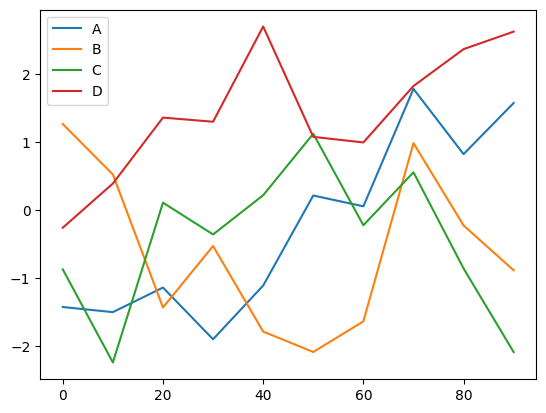

In [ ]:
# Using Dataframe
rng = np.random.default_rng(12345)
df = pd.DataFrame(rng.standard_normal((10, 4)).cumsum(0),
                  columns=['A', 'B', 'C', 'D'],
                  index=np.arange(0, 100, 10))
df.plot();

In [ ]:
# Show df content
df

,A,B,C,D
0,-1.423825,1.263728,-0.870662,-0.259173
10,-1.499168,0.522844,-2.238454,0.389720
20,-1.138110,-1.430019,0.108955,1.358216
30,-1.897497,-0.527821,-0.357998,1.297527
40,-1.108653,-1.784489,0.217860,2.696506
50,0.213645,-2.084188,1.120779,1.074923
60,0.055456,-1.634704,-0.222822,0.993236
70,1.780196,0.983456,0.554539,1.821869
80,0.821207,-0.225933,-0.857753,2.363416
90,1.573147,-0.884693,-2.086428,2.620973


### **Bar plots**

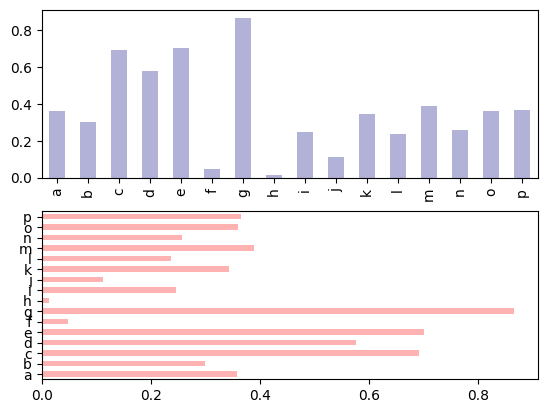

In [ ]:
# Series data
fig, axes = plt.subplots(2, 1)
data = pd.Series(np.random.uniform(size=16), index=list('abcdefghijklmnop'))

# Plot.bar is for plotting vertical bar
data.plot.bar(ax=axes[0], color='navy', alpha=0.3)

# Plot.barh is for plotting horizontal bar
data.plot.barh(ax=axes[1], color='red', alpha=0.3);

In [ ]:
# Example DataFrame
df = pd.DataFrame(np.random.uniform(size=(6, 4)),
                  index=['one', 'two', 'three', 'four', 'five', 'six'],
                  columns=pd.Index(['A', 'B', 'C', 'D'], name='Genus'))
df

Genus,A,B,C,D
one,0.524086,0.897590,0.008161,0.538638
two,0.903216,0.231702,0.275936,0.909991
three,0.037097,0.364632,0.846644,0.832405
four,0.873468,0.817817,0.976245,0.786403
five,0.907907,0.118351,0.189823,0.270301
six,0.822443,0.059165,0.879308,0.374409


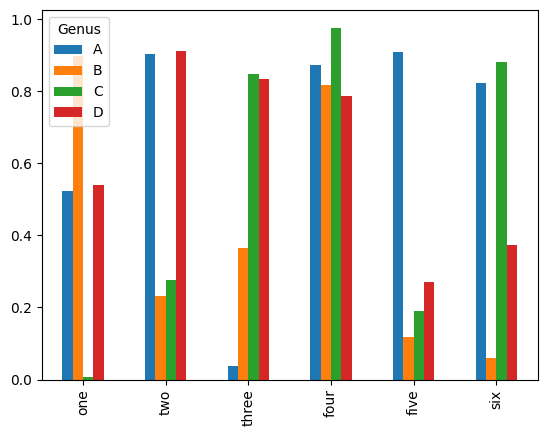

In [ ]:
# Grouped bar plot
df.plot.bar();

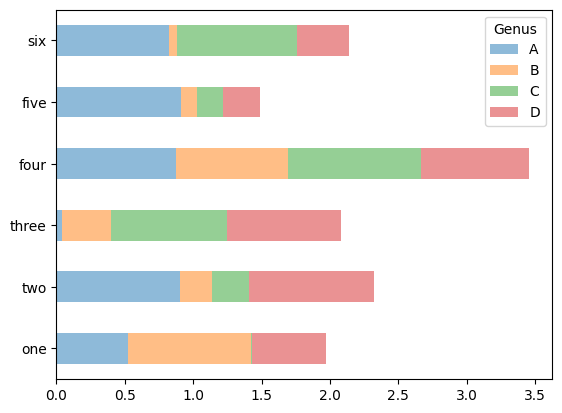

In [ ]:
# Stacked bar plots
df.plot.barh(stacked=True, alpha=0.5);

In [ ]:
# A dataset about restaurant tipping
tips = pd.read_csv('https://bit.ly/3jCROII')

In [ ]:
# Show tips content
tips

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4
...,...,...,...,...,...,...
239,29.03,5.92,No,Sat,Dinner,3
240,27.18,2.00,Yes,Sat,Dinner,2
241,22.67,2.00,Yes,Sat,Dinner,2
242,17.82,1.75,No,Sat,Dinner,2


In [ ]:
# Create a frequency table
party_counts = pd.crosstab(tips['day'], tips['size'], margins=True)
party_counts

size,1,2,3,4,5,6,All
day,,,,,,,
Fri,1,16,1,1,0,0,19
Sat,2,53,18,13,1,0,87
Sun,0,39,15,18,3,1,76
Thur,1,48,4,5,1,3,62
All,4,156,38,37,5,4,244


In [ ]:
# Reorder the index
party_counts = party_counts.reindex(index=['Thur', 'Fri', 'Sat', 'Sun'])
party_counts

size,1,2,3,4,5,6,All
day,,,,,,,
Thur,1,48,4,5,1,3,62
Fri,1,16,1,1,0,0,19
Sat,2,53,18,13,1,0,87
Sun,0,39,15,18,3,1,76


In [ ]:
# Extract party_count from col 2 to 5
party_counts = party_counts.loc[:, 2:5]

In [ ]:
# Show content for party_counts
party_counts

size,2,3,4,5
day,,,,
Thur,48,4,5,1
Fri,16,1,1,0
Sat,53,18,13,1
Sun,39,15,18,3


In [ ]:
# Normalize each row to sum to 1
party_pcts = party_counts.div(party_counts.sum(axis='columns'),
                              axis=0)
party_pcts

size,2,3,4,5
day,,,,
Thur,0.827586,0.068966,0.086207,0.017241
Fri,0.888889,0.055556,0.055556,0.000000
Sat,0.623529,0.211765,0.152941,0.011765
Sun,0.520000,0.200000,0.240000,0.040000


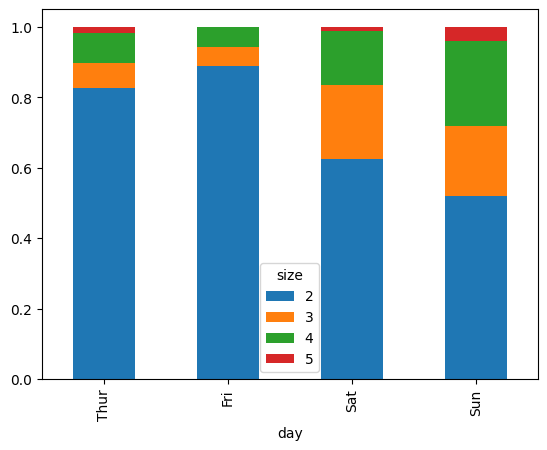

In [ ]:
# Stacked bar plot
party_pcts.plot.bar(stacked=True);

### **Using seaborn package**

In [ ]:
# Show content for tips
tips

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4
...,...,...,...,...,...,...
239,29.03,5.92,No,Sat,Dinner,3
240,27.18,2.00,Yes,Sat,Dinner,2
241,22.67,2.00,Yes,Sat,Dinner,2
242,17.82,1.75,No,Sat,Dinner,2


In [ ]:
# Add a new column for 'tip_pct'
tips['tip_pct'] = tips['tip'] / (tips['total_bill'] - tips['tip'])

In [ ]:
# Show top five rows
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069


### **Notes:**
In **`sns.barplot()`**, the bar height usually represents the mean value for each category.
- The black error bars show uncertainty around the mean.
- By default, seaborn uses a 95% confidence interval.

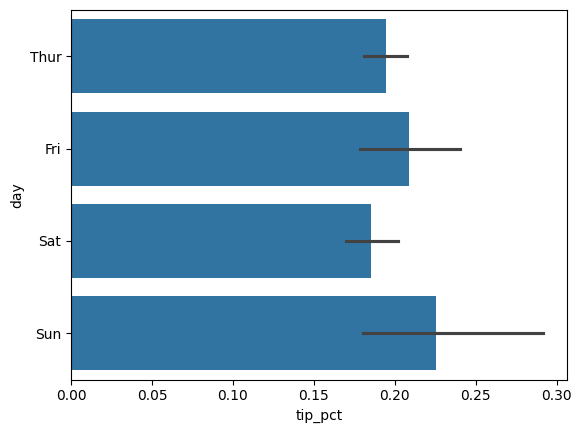

In [ ]:
# Using black lines on the bars to represent 95% confidence interval
sns.barplot(x='tip_pct', y='day', data=tips, orient='h',
            order=['Thur', 'Fri', 'Sat', 'Sun']);

### **`hue`**
- `hue` helps to visualize the impact of an **additional categorical variable** on
our main comparison.

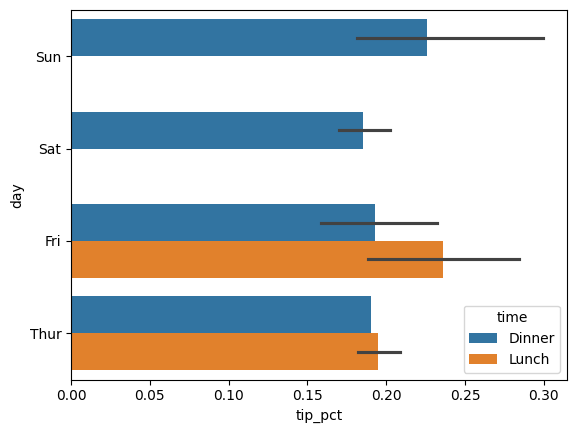

In [ ]:
# Using hue to add a categorical distinction
sns.barplot(x='tip_pct', y='day', hue='time', data=tips, orient='h',
            order=['Sun', 'Sat', 'Fri', 'Thur']);

### **Histograms and Density Plots**

- A **histogram** divides a **numerical variable** into intervals called bins and counts how many observations fall into each bin.

- A **density plot** shows a smoothed estimate of the distribution. It is useful for understanding the overall shape of the data.

In [ ]:
# Display top few rows
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069


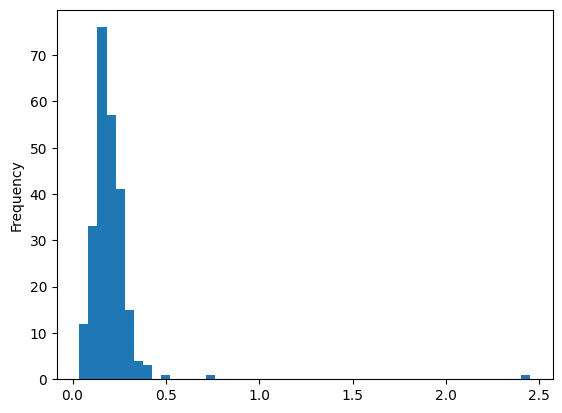

In [ ]:
# Histogram
tips['tip_pct'].plot.hist(bins=50);

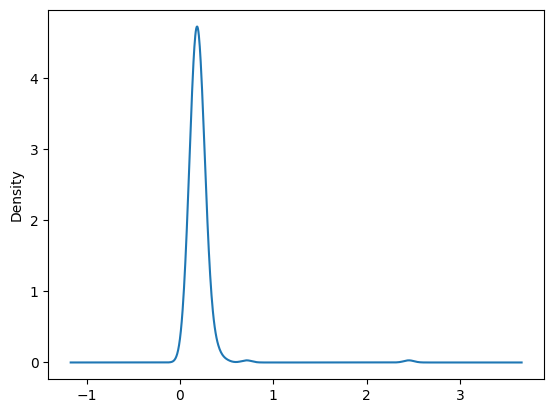

In [ ]:
# Density plot
tips['tip_pct'].plot.density();

### **Scatter or Point Plots**
- examining the relationship between two one-dimensional data series

#### **Macro dataset**
- Collection of economic data points that reflect the overall performance and health of a country, region, or the global economy.
- **`m1`** represents the M1 money supply
    - a measure of the most liquid forms of money within an economy, typically including physical currency (cash), demand deposits (checking accounts), and traveler's checks.
- **`tbilrate`** is Treasury Bill Rate.
    - the interest rate at which the government borrows money for short periods (usually less than a year) by issuing Treasury Bills.

In [ ]:
# Example macro dataset
macro = pd.read_csv('https://bit.ly/3FYxCYZ')
macro

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
2,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
3,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
4,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2008,3,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008,4,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009,1,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009,2,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19


In [ ]:
# Only select a few variables
data = macro[['cpi', 'm1', 'tbilrate', 'unemp']]
data

,cpi,m1,tbilrate,unemp
0,28.980,139.7,2.82,5.8
1,29.150,141.7,3.08,5.1
2,29.350,140.5,3.82,5.3
3,29.370,140.0,4.33,5.6
4,29.540,139.6,3.50,5.2
...,...,...,...,...
198,216.889,1474.7,1.17,6.0
199,212.174,1576.5,0.12,6.9
200,212.671,1592.8,0.22,8.1
201,214.469,1653.6,0.18,9.2


# **Log Transformation**

A log transformation is often used for economic or financial variables because it can reduce the effect of **very large values** and make changes easier to compare.

The code below applies three steps:

1. **`np.log(data)`**: transforms each value using the natural logarithm.
2. **`.diff()`**: calculates the change from one row to the next.
3. **`.dropna()`**: removes the first row because differencing creates a missing value.

In [ ]:
# Applies a logarithmic transformation
# Calculates the difference between consecutive values
# Removes any rows with missing values (NaN)
logtrans_data = np.log(data).diff().dropna()

# Display content
logtrans_data

,cpi,m1,tbilrate,unemp
1,0.005849,0.014215,0.088193,-0.128617
2,0.006838,-0.008505,0.215321,0.038466
3,0.000681,-0.003565,0.125317,0.055060
4,0.005772,-0.002861,-0.212805,-0.074108
5,0.000338,0.004289,-0.266946,0.000000
...,...,...,...,...
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339


In [ ]:
# Display top few rows for data
data.head()

,cpi,m1,tbilrate,unemp
0,28.98,139.7,2.82,5.8
1,29.15,141.7,3.08,5.1
2,29.35,140.5,3.82,5.3
3,29.37,140.0,4.33,5.6
4,29.54,139.6,3.50,5.2


In [ ]:
# Display contents for logtrans_data
logtrans_data

,cpi,m1,tbilrate,unemp
1,0.005849,0.014215,0.088193,-0.128617
2,0.006838,-0.008505,0.215321,0.038466
3,0.000681,-0.003565,0.125317,0.055060
4,0.005772,-0.002861,-0.212805,-0.074108
5,0.000338,0.004289,-0.266946,0.000000
...,...,...,...,...
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339


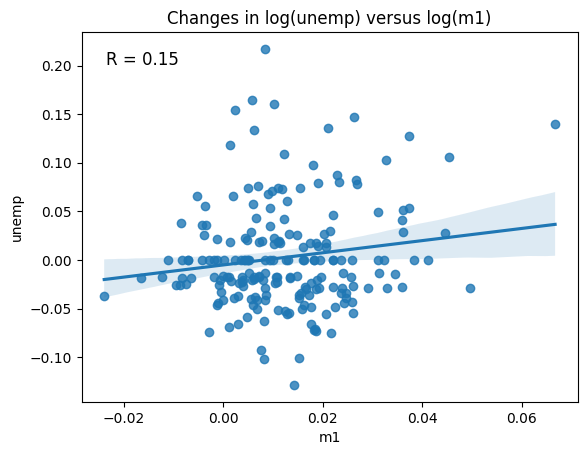

In [ ]:
# Generate scatter plot with regression line
fig, ax = plt.subplots()
sns.regplot(x='m1', y='unemp', data=logtrans_data, ax=ax)

# Calculate the R-value
r_value = logtrans_data['m1'].corr(logtrans_data['unemp'])

# Add the R-value as text directly on the plot
# 0.05 means 5% of the way from the left edge,
# 0.95 means 95% of the way from the bottom edge (or 5% from the top edge)
ax.text(0.05, 0.95, f'R = {r_value:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')

# Set the title (without R-value)
ax.set(title='Changes in log(unemp) versus log(m1)');

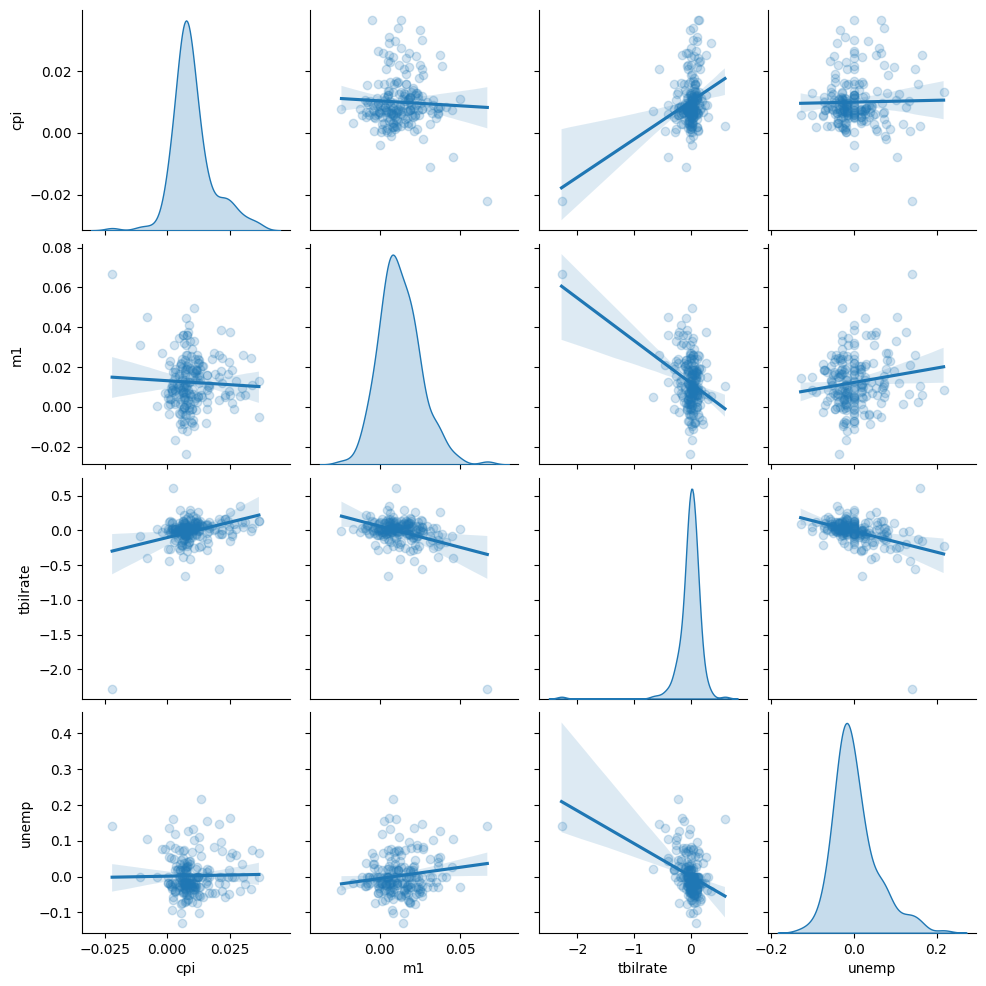

In [ ]:
# kde = kernel density estimate - another name for density plot
# Estimate of the continuous probability distribution
# `scatter_kws` -> scatter keyword arguments
sns.pairplot(logtrans_data, diag_kind='kde', kind='reg',
             plot_kws={'scatter_kws': {'alpha': 0.2}});

### **Facet Grids and Categorical Data**
visualize data with many ***categorical variables***

Seaborn **catplot** function simplifies making many kinds of faceted plots split by ***categorical variables***

In data visualisation, a **facet** is a small plot created for each subgroup of the data.
- Faceting is useful when we want to compare patterns across categories, such as
    - **smoker vs non-smoker**, or
    - **lunch vs dinner**

In [ ]:
# Display contents for tips dataframe
tips

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069
...,...,...,...,...,...,...,...
239,29.03,5.92,No,Sat,Dinner,3,0.256166
240,27.18,2.00,Yes,Sat,Dinner,2,0.079428
241,22.67,2.00,Yes,Sat,Dinner,2,0.096759
242,17.82,1.75,No,Sat,Dinner,2,0.108899


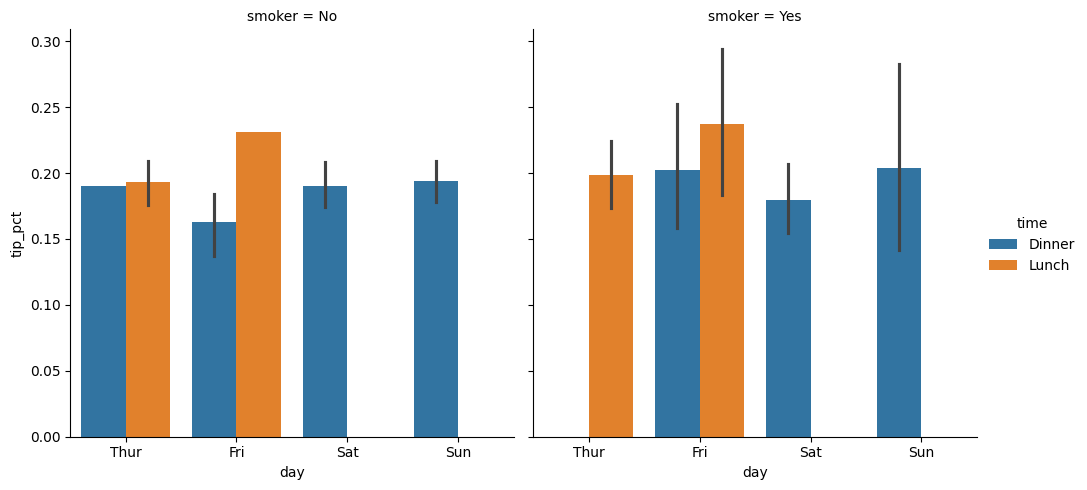

In [ ]:
# Generate categorical plot
# col='smoker' -> plots will be arranged in columns based on smoker status
sns.catplot(x='day', y='tip_pct', hue='time', col='smoker',
            kind='bar', data=tips[tips.tip_pct < 1],
            order=['Thur', 'Fri', 'Sat', 'Sun']);

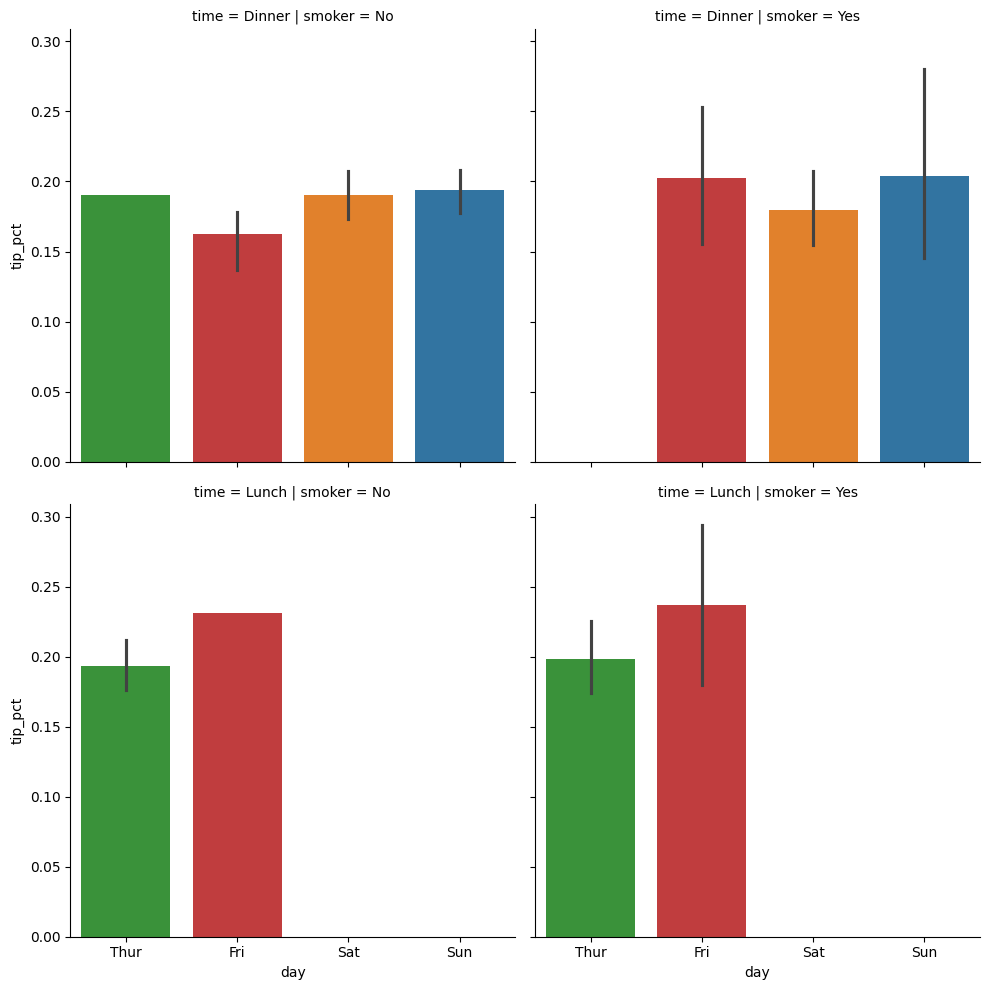

In [ ]:
# Generate categorical plot
sns.catplot(x='day', y='tip_pct', row='time',
            col='smoker', hue='day', order=['Thur', 'Fri', 'Sat', 'Sun'],
            kind='bar', data=tips[tips.tip_pct < 1]);

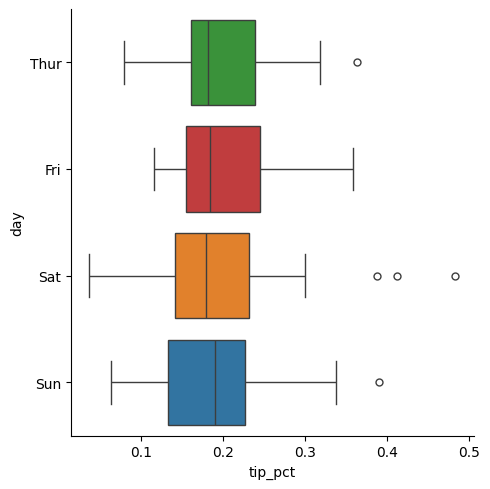

In [ ]:
# Generate categorical plot: boxplot
sns.catplot(x='tip_pct', y='day', hue='day', kind='box',
            data=tips[tips.tip_pct < 0.5], order=['Thur', 'Fri', 'Sat', 'Sun']);

# **Summary**

In this lesson, we learned how to:

- create basic plots using Matplotlib;
- understand the difference between Figure and Axes;
- customise plots using titles, labels, ticks, colours, markers, line styles, and legends;
- arrange multiple plots using subplots;
- save figures to external files;
- use pandas and seaborn to create common statistical visualisations more efficiently.

The key idea is that Matplotlib provides the foundation, while pandas and seaborn offer convenient shortcuts for common plotting tasks.

# **Practice Exercises**

1. Create a line plot showing the cumulative sum of 100 random values.
2. Add a title, x-axis label, y-axis label, and legend to the plot.
3. Create a 2 × 2 subplot grid containing a histogram, scatter plot, line plot, and boxplot.
4. Save one of your plots as a PNG file.
5. Using the `tips` dataset, create a seaborn bar plot comparing `tip_pct` across different days.

# **That's it for the day!!! :)**